# 7. Hyperparameters Optimization

In [8]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from chess_eval import *

## 7.0 Introduction

For this notebook we will take each of the three classes that have passed the initial testing from notebook `6_models.ipynb` and we will optimize each one individually in a separate section. At all times, we will be using cross-validation to check for possible overfitting. At the end of each section, we will choose the subset of parameters which outputs the best result in each case. In the last section, we will compare the three models and make our final choice.

In [6]:
sm = StorageManager()
dm = load_dataset("one")

## 7.1 Ridge

In [ ]:
ridge_param_grid = {
    "alpha": [0.001, 0.01, 0.1, 1, 10, 100, 1000]
}

ridge_mm = ModelManager(Ridge())

In [ ]:
ridge_grid, ridge_best_params, ridge_best_score = ridge_mm.optimize_hyperparameters(dm, ridge_param_grid)  # ~1 minutes 30 seconds
display(ridge_best_params)
display(ridge_best_score)
MetricsManager.plot_gridsearch_results(ridge_grid, log=True, save=True, file="rdg")

## 7.2 XGBRegressor

In [ ]:
xgbr_param_grid = {
    "learning_rate" : [0.01, 0.05, 0.1, 0.2, 0.3],
    "n_estimators": [100, 500, 1000, 2000, 3000],
    "max_depth": [3, 6, 9, 12],
    "gamma": [0, 2.5, 5],
}

xgbr_mm = ModelManager(XGBRegressor())

In [ ]:
xgbr1_param_grid = {k: xgbr_param_grid[k] for k in ["learning_rate", "n_estimators"]}
xgbr1_grid, xgbr1_best_params, xgbr1_best_score = xgbr_mm.optimize_hyperparameters(dm, xgbr1_param_grid)  # ~TODO: time
display(xgbr1_best_params)
display(xgbr1_best_score)
MetricsManager.plot_gridsearch_results(xgbr1_grid, save=True, file="xgb_1")

In [ ]:
# TODO: create model with best params found above

xgbr2_param_grid = {k: xgbr_param_grid[k] for k in ["learning_rate", "n_estimators"]}
xgbr2_grid, xgbr2_best_params, xgbr2_best_score = xgbr_mm.optimize_hyperparameters(dm, xgbr2_param_grid)  # ~TODO: time
display(xgbr2_best_params)
display(xgbr2_best_score)
MetricsManager.plot_gridsearch_results(xgbr2_grid, save=True, file="xgb_2")

## 7.3 KNeighborsRegressor

First, we recall that this model uses distances as its main tool to determine the prediction. That means that it works at its best when the data is normalized properly.

In [4]:
knn_param_grid = {
    "knn__n_neighbors": list(range(1, 10)) + list(range(10, 200, 10)),
}

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsRegressor()),
])

knn_mm = ModelManager(pipeline)

{'knn__n_neighbors': 50}

np.float64(0.44473952828580154)

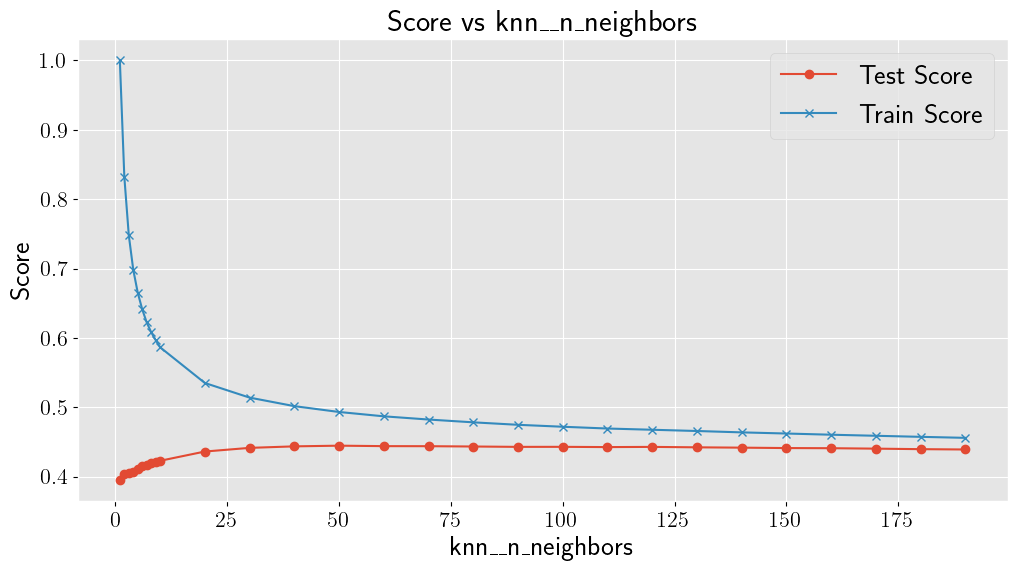

In [7]:
knn_grid, knn_best_params, knn_best_score = knn_mm.optimize_hyperparameters(dm, knn_param_grid)  # ~50 minutes
display(knn_best_params)
display(knn_best_score)
MetricsManager.plot_gridsearch_results(knn_grid, save=True, file="knn")